<a href="https://colab.research.google.com/github/Dipu1764/Data-analyst-internship-task-7/blob/DATA/SQLite_Sales_Summary_with_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#Create a tiny SQLite database with sample data

conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

# Drop table if it already exists (for repeat runs)
cursor.execute("DROP TABLE IF EXISTS sales")

# Create table
cursor.execute("""
CREATE TABLE sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")

In [3]:
# Insert some sample sales data
sample_data = [
    ("Apples", 10, 2.5),
    ("Apples", 5, 2.5),
    ("Bananas", 8, 1.8),
    ("Bananas", 12, 1.8),
    ("Cherries", 6, 3.0),
    ("Cherries", 4, 3.0),
    ("Dates", 15, 5.0),
    ("Dates", 10, 5.0)
]
cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sample_data)
conn.commit()

In [4]:
#Query: Get total quantity and revenue per product
# -----------------------------
query = """
SELECT
    product,
    SUM(quantity) AS total_qty,
    SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
"""

df = pd.read_sql_query(query, conn)


In [5]:
#Display results in console
print("Sales Summary:")
print(df)

Sales Summary:
    product  total_qty  revenue
0    Apples         15     37.5
1   Bananas         20     36.0
2  Cherries         10     30.0
3     Dates         25    125.0


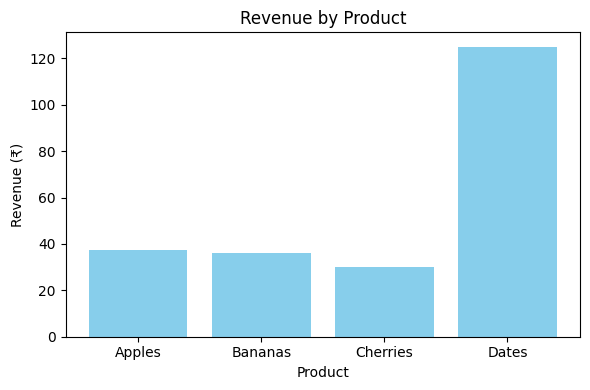

In [6]:
#Create a simple bar chart for revenue
plt.figure(figsize=(6,4))
plt.bar(df['product'], df['revenue'], color='skyblue')
plt.xlabel("Product")
plt.ylabel("Revenue (₹)")
plt.title("Revenue by Product")
plt.tight_layout()
plt.savefig("sales_chart.png")  # Save chart
plt.show()

# Close connection
conn.close()